Classification problem with input features as Feature1 and Feature2 and the dependent variable is Target

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")
df

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No
...,...,...,...
1015,1.8500,492,No
1016,1.7375,412,No
1017,1.6375,444,No
1018,1.6625,632,No


Exploratory data analysis

In [4]:
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB


In [6]:
df.describe()

,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [7]:
missing_values = df.isnull().sum()
missing_values

,0
Feature1,0
Feature2,0
Target,20


In [8]:
print(df.duplicated().sum())

102


In [9]:
print(df['Target'].value_counts())


Target
No     785
Yes    215
Name: count, dtype: int64


In [10]:
df['Target'] = df['Target'].map({'Yes':1,'No':0})


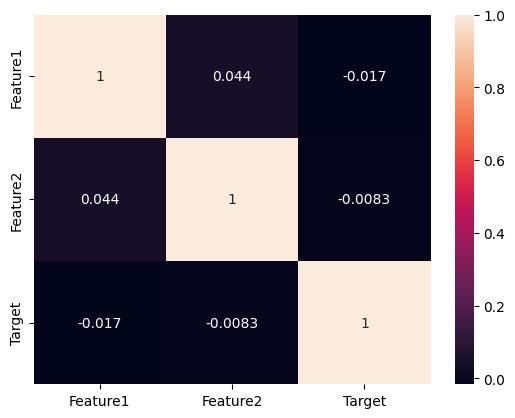

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

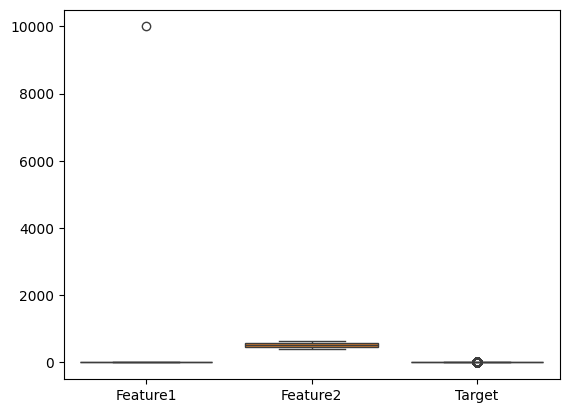

In [12]:
sns.boxplot(data=df)
plt.show()

In [13]:
Q1 = df['Feature1'].quantile(0.25)
Q3 = df['Feature1'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 1.45
Q3: 1.828125
IQR: 0.37812500000000004


In [14]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Feature1'] < lower_bound) | (df['Feature1'] > upper_bound)]
print(outliers)

     Feature1  Feature2  Target
132   10000.0       620     0.0


In [15]:
Q1 = df['Feature1'].quantile(0.25)
Q3 = df['Feature1'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[(df['Feature1'] >= lower_bound) & (df['Feature1'] <= upper_bound)]

In [16]:
Q1 = df['Feature2'].quantile(0.25)
Q3 = df['Feature2'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 464.0
Q3: 584.0
IQR: 120.0


In [17]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Feature2'] < lower_bound) | (df['Feature2'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [Feature1, Feature2, Target]
Index: []


Logistic Regression

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
X = df.drop('Target', axis=1)
y = df['Target']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = LogisticRegression()

In [22]:
df = df.dropna(subset=['Target'])

In [23]:
print(y_train.isnull().sum())

13


In [24]:
# Remove NaN target
df = df.dropna(subset=['Target'])

# Split X and y
X = df.drop('Target', axis=1)
y = df['Target']

In [28]:


# Clean target
df['Target'] = df['Target'].astype(str).str.strip().str.lower()
df['Target'] = df['Target'].map({'yes':1, 'no':0})

# Remove NaN target
df = df.dropna(subset=['Target'])

# Split
X = df.drop('Target', axis=1)
y = df['Target']

# Convert categorical
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(0)


Decision Boundary plot

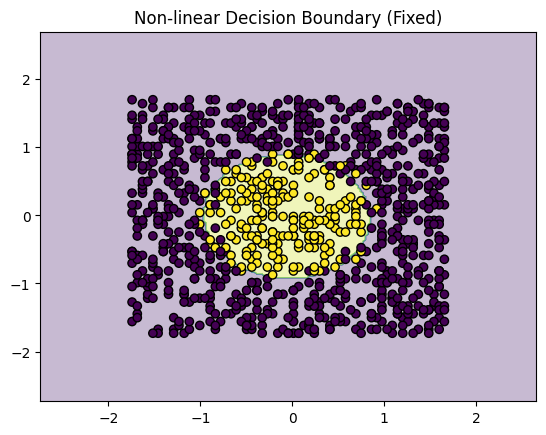

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Features
X = df_cleaned_for_training[['Feature1', 'Feature2']].values
y = df_cleaned_for_training['Target'].values

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Add polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_poly, y)

# Mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Transform grid also!
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid)

# Predict
Z = model.predict(grid_poly)
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.title("Non-linear Decision Boundary (Fixed)")
plt.show()

Evaluate and report model performance

In [48]:

df_cleaned_for_training = df_clean.dropna(subset=['Target'])

X = df_cleaned_for_training.drop('Target', axis=1)
y = df_cleaned_for_training['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Model
model = LogisticRegression()

# 🔹 Train
model.fit(X_train, y_train)

# 🔹 Predict
y_pred = model.predict(X_test)

# 🔹 Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.79
Confusion Matrix:
 [[158   0]
 [ 42   0]]


In [49]:
conf_matrix = confusion_matrix(y_pred, y_test)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[158  42]
 [  0   0]]


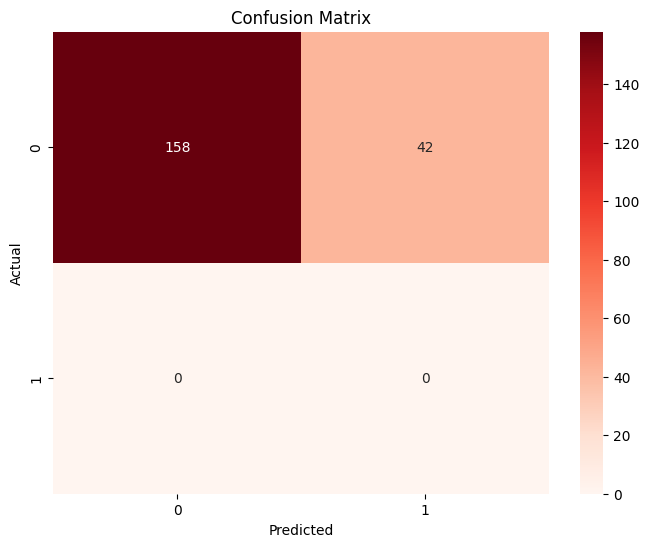

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [51]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      1.00      0.88       158
         1.0       0.00      0.00      0.00        42

    accuracy                           0.79       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.62      0.79      0.70       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
